In [1]:
# VaccineNLP — Model Benchmark Report
# Auto-generated comparison: PhoBERT-v2 | XLM-R-v1 | Gemma-4 4B
# Taxonomy v3: Misinfo(2) | Stance(3) | Sentiment(3)
# Gold Test Set: 186 samples (Human-validated, HUPH 2026)

import os, json, glob
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix

# ── Taxonomy v3 ──────────────────────────────────────────────────────────
N_CLASSES = {'misinfo': 2, 'stance': 3, 'sentiment': 3}
HC_NAMES  = {
    'misinfo':   ['Tin giả',   'Chính xác'],
    'stance':    ['Ủng hộ',    'Phản đối',   'Trung lập'],
    'sentiment': ['Tiêu cực',  'Trung tính',  'Tích cực'],
}
TASKS     = list(N_CLASSES.keys())
MODEL_DISPLAY = {
    'phobert': 'PhoBERT-v2',
    'xlmr':    'XLM-R-v1',
    'gemma':   'Gemma-4 4B (XAI)',
}
REPORT_DIR = '/kaggle/working/benchmark_report'
os.makedirs(REPORT_DIR, exist_ok=True)
print("✅ Config loaded — Taxonomy v3")

✅ Config loaded — Taxonomy v3


In [2]:
# Load kết quả từ các notebook trước — tự động tìm file JSON
# Fallback hardcoded nếu không tìm thấy

def find_result(fnames, dirs_extra=None):
    dirs = (dirs_extra or []) + [
        '/kaggle/working/phobert_v2',
        '/kaggle/working/xlm-roberta-base',
        '/kaggle/working/gemma_qlora_xai',
    ]
    for d in dirs:
        for fn in fnames:
            p = os.path.join(d, fn)
            if os.path.exists(p):
                with open(p) as f:
                    return json.load(f), p
    for fn in fnames:
        hits = glob.glob(f'/kaggle/input/**/{fn}', recursive=True)
        if hits:
            with open(hits[0]) as f:
                return json.load(f), hits[0]
    return None, None

FALLBACK = {
    'phobert': {
        'model':'phobert-v2','timestamp':'2026-05-13',
        'misinfo':   {'macro_f1':0.6886,'per_class':[0.4933,0.8839],'support':[28,158]},
        'stance':    {'macro_f1':0.6383,'per_class':[0.5817,0.6316,0.6923],'support':[54,48,84]},
        'sentiment': {'macro_f1':0.7289,'per_class':[0.7606,0.7671,0.6600],'support':[71,75,40]},
    },
    'xlmr': {
        'model':'xlmr-base','timestamp':'2026-05-13',
        'misinfo':   {'macro_f1':0.6632,'per_class':[0.4478,0.8785],'support':[28,158]},
        'stance':    {'macro_f1':0.5618,'per_class':[0.4706,0.5660,0.6489],'support':[54,48,84]},
        'sentiment': {'macro_f1':0.6394,'per_class':[0.6993,0.6618,0.5571],'support':[71,75,40]},
    },
    'gemma': {
        'model':'gemma-4-4b-xai','timestamp':'2026-05-13',
        'misinfo':   {'macro_f1':0.3588,'per_class':[0.3429,0.3747],'support':[28,158]},
        'stance':    {'macro_f1':0.2862,'per_class':[0.5660,0.3721,0.5106],'support':[54,48,84]},
        'sentiment': {'macro_f1':0.2883,'per_class':[0.5623,0.1579,0.0247],'support':[71,75,40]},
    },
}

results = {}
sources = {}
search_map = {
    'phobert': (['benchmark_results.json','phobert_v2_results.json'],
                ['/kaggle/working/phobert_v2']),
    'xlmr':    (['xlmr_v1_results.json','benchmark_results.json'],
                ['/kaggle/working/xlm-roberta-base']),
    'gemma':   (['gemma_v3_results.json','gemma_v2_results.json'],
                ['/kaggle/working/gemma_qlora_xai']),
}
for key, (fnames, dirs) in search_map.items():
    res, path = find_result(fnames, dirs)
    if res:
        results[key] = res
        sources[key] = f"Loaded: {path}"
    else:
        results[key] = FALLBACK[key]
        sources[key] = "Fallback (hardcoded 2026-05-13)"

print("DATA SOURCES:")
for k in ['phobert', 'xlmr', 'gemma']:
    ts = results[k].get('timestamp', '?')[:10]
    print(f"  {MODEL_DISPLAY[k]:<22}: {sources[k]}")

DATA SOURCES:
  PhoBERT-v2            : Loaded: /kaggle/input/notebooks/kimmnhhng/vaccinenlp-phobert-v2-multitask-classifier/phobert_v2/benchmark_results.json
  XLM-R-v1              : Loaded: /kaggle/input/notebooks/kimmnhhng/vaccinenlp-xlm-r-v1-multitask-classifier/xlm-roberta-base/xlmr_v1_results.json
  Gemma-4 4B (XAI)      : Loaded: /kaggle/input/notebooks/kimmnhhng/vaccinenlp-gemma-4-qlora-multitask/gemma_v2_results.json


In [3]:
# ── Bảng Macro F1 tổng hợp ────────────────────────────────────────────
ORDER = ['xlmr', 'phobert', 'gemma']

print("=" * 72)
print("  BENCHMARK — Macro F1 (Gold Test Set, n=186)")
print("  Taxonomy v3: Misinfo(2cls) | Stance(3cls) | Sentiment(3cls)")
print("=" * 72)
print(f"  {'Mô hình':<24} {'Misinfo':>9} {'Stance':>9} {'Sentiment':>11} {'TB':>8}")
print("-" * 72)
for k in ORDER:
    r   = results[k]
    m   = r['misinfo']['macro_f1']
    st  = r['stance']['macro_f1']
    se  = r['sentiment']['macro_f1']
    avg = round((m + st + se) / 3, 4)
    name = MODEL_DISPLAY[k]
    print(f"  {name:<24} {m:>9.4f} {st:>9.4f} {se:>11.4f} {avg:>8.4f}")
print("=" * 72)

# Best per task
print("\n  Best per task:")
for task in TASKS:
    best_k = max(ORDER, key=lambda k: results[k][task]['macro_f1'])
    best_v = results[best_k][task]['macro_f1']
    print(f"  {task:<12}: {MODEL_DISPLAY[best_k]} ({best_v:.4f}) ✅")

  BENCHMARK — Macro F1 (Gold Test Set, n=186)
  Taxonomy v3: Misinfo(2cls) | Stance(3cls) | Sentiment(3cls)
  Mô hình                    Misinfo    Stance   Sentiment       TB
------------------------------------------------------------------------
  XLM-R-v1                    0.6201    0.6019      0.6774   0.6331
  PhoBERT-v2                  0.7121    0.6763      0.7305   0.7063
  Gemma-4 4B (XAI)            0.3588    0.2862      0.2883   0.3111

  Best per task:
  misinfo     : PhoBERT-v2 (0.7121) ✅
  stance      : PhoBERT-v2 (0.6763) ✅
  sentiment   : PhoBERT-v2 (0.7305) ✅


In [4]:
# ── Per-class F1 breakdown ────────────────────────────────────────────
print("=" * 72)
print("  PER-CLASS F1 — Gold Test Set (n=186), Taxonomy v3")
print("=" * 72)

model_names = [MODEL_DISPLAY[k] for k in ORDER]
for task in TASKS:
    labels = HC_NAMES[task]
    print(f"\n  {task.upper()} (Macro: " +
          " | ".join(f"{MODEL_DISPLAY[k]}={results[k][task]['macro_f1']:.4f}"
                     for k in ORDER) + ")")
    print(f"  {'Nhãn':<18}" +
          "".join(f"{n:>14}" for n in model_names) +
          "  Support")
    print(f"  {'-'*65}")
    for c, lbl in enumerate(labels):
        row  = []
        for k in ORDER:
            pc = results[k][task]['per_class']
            row.append(f"{pc[c]:.4f}" if c < len(pc) else "   -   ")
        sup = results['phobert'][task]['support']
        sv  = sup[c] if c < len(sup) else 0
        print(f"  {lbl:<18}" +
              "".join(f"{v:>14}" for v in row) +
              f"  {sv:>6}")

  PER-CLASS F1 — Gold Test Set (n=186), Taxonomy v3

  MISINFO (Macro: XLM-R-v1=0.6201 | PhoBERT-v2=0.7121 | Gemma-4 4B (XAI)=0.3588)
  Nhãn                    XLM-R-v1    PhoBERT-v2Gemma-4 4B (XAI)  Support
  -----------------------------------------------------------------
  Tin giả                   0.4301        0.5294        0.0000      28
  Chính xác                 0.8100        0.8947        0.5672     158

  STANCE (Macro: XLM-R-v1=0.6019 | PhoBERT-v2=0.6763 | Gemma-4 4B (XAI)=0.2862)
  Nhãn                    XLM-R-v1    PhoBERT-v2Gemma-4 4B (XAI)  Support
  -----------------------------------------------------------------
  Ủng hộ                    0.4835        0.6170        0.5049      54
  Phản đối                  0.6512        0.6667        0.6400      48
  Trung lập                 0.6711        0.7453        0.0000      84

  SENTIMENT (Macro: XLM-R-v1=0.6774 | PhoBERT-v2=0.7305 | Gemma-4 4B (XAI)=0.2883)
  Nhãn                    XLM-R-v1    PhoBERT-v2Gemma-4 4B (XA

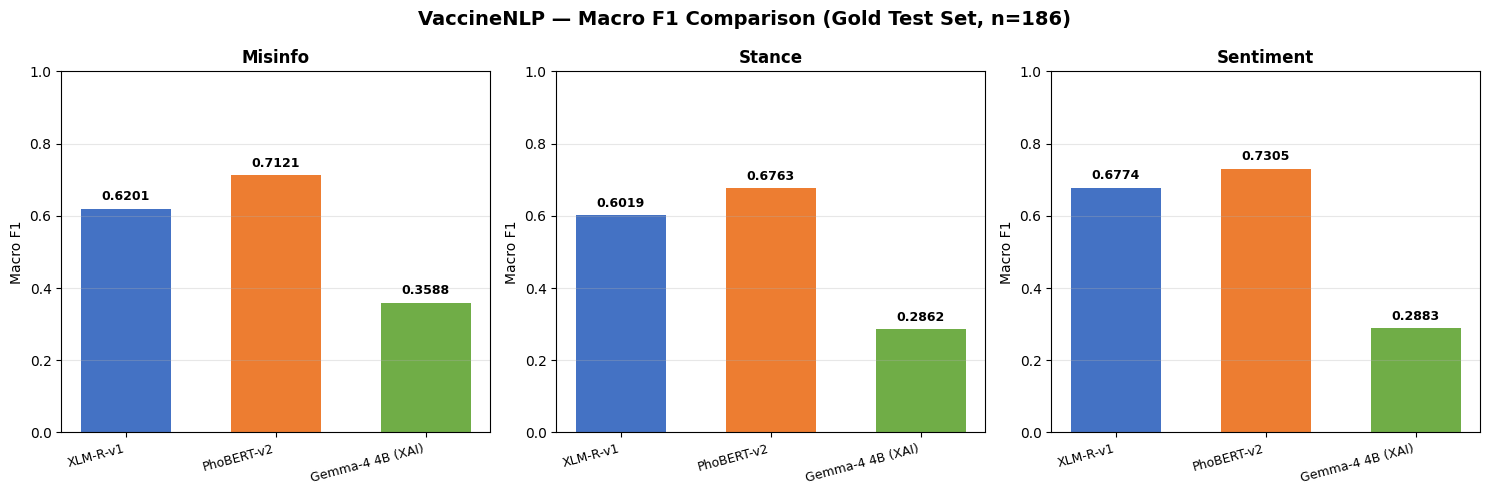

✅ Saved: /kaggle/working/benchmark_report/macro_f1_comparison.png


In [5]:
# ── Bar Chart: Macro F1 per Task ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'VaccineNLP — Macro F1 Comparison (Gold Test Set, n=186)',
    fontsize=14, fontweight='bold'
)

colors = {'xlmr': '#4472C4', 'phobert': '#ED7D31', 'gemma': '#70AD47'}
x = np.arange(len(ORDER))
width = 0.6

for ax_i, task in enumerate(TASKS):
    vals  = [results[k][task]['macro_f1'] for k in ORDER]
    names = [MODEL_DISPLAY[k] for k in ORDER]
    bars  = axes[ax_i].bar(x, vals, width,
                           color=[colors[k] for k in ORDER])
    axes[ax_i].set_ylim(0, 1.0)
    axes[ax_i].set_xticks(x)
    axes[ax_i].set_xticklabels(names, fontsize=9, rotation=15, ha='right')
    axes[ax_i].set_title(task.capitalize(), fontweight='bold')
    axes[ax_i].set_ylabel('Macro F1')
    axes[ax_i].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        axes[ax_i].text(
            bar.get_x() + bar.get_width()/2,
            val + 0.015, f'{val:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

plt.tight_layout()
chart_path = f'{REPORT_DIR}/macro_f1_comparison.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {chart_path}")

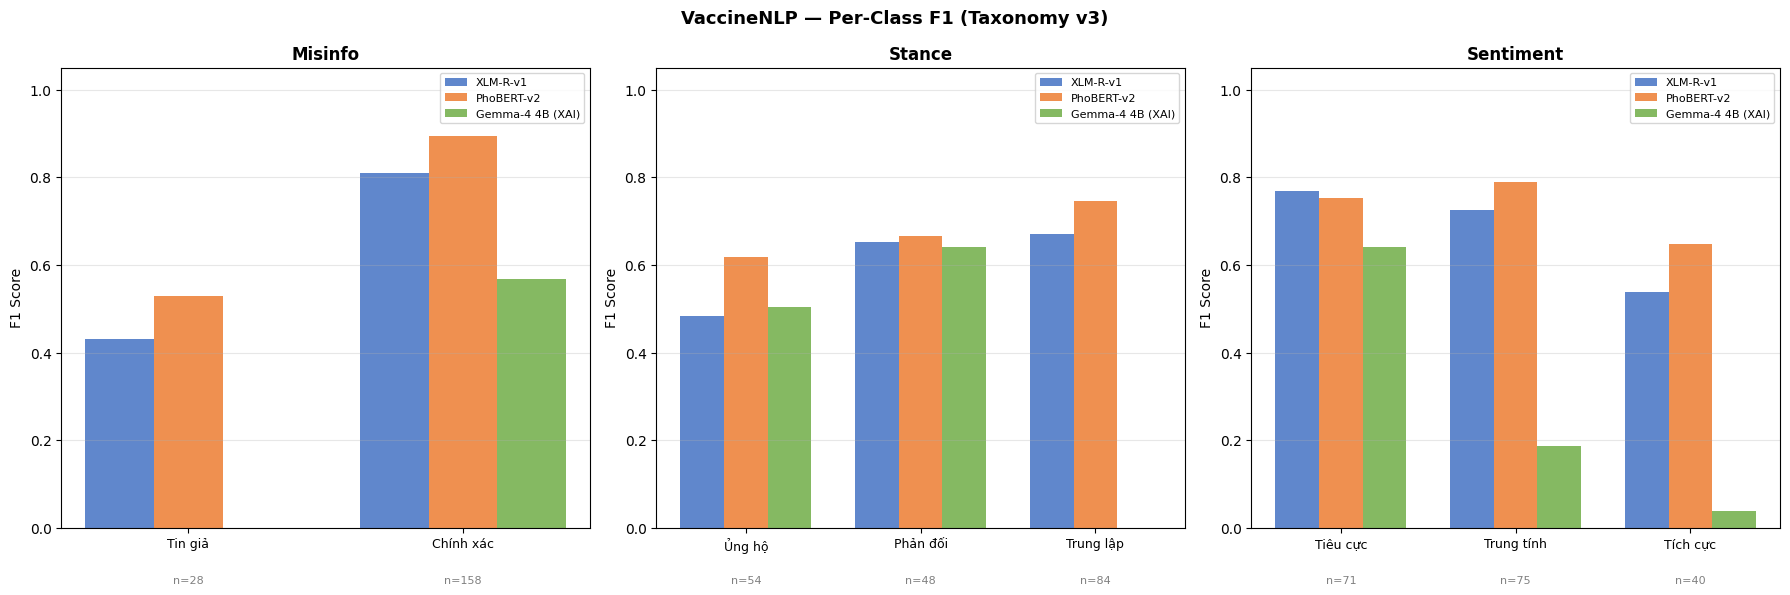

✅ Saved: /kaggle/working/benchmark_report/per_class_f1.png


In [6]:
# ── Per-class F1 Grouped Bar Chart ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'VaccineNLP — Per-Class F1 (Taxonomy v3)',
    fontsize=13, fontweight='bold'
)
plt.subplots_adjust(bottom=0.15)

colors_m = ['#4472C4', '#ED7D31', '#70AD47']  # xlmr, phobert, gemma
for ax_i, task in enumerate(TASKS):
    labels = HC_NAMES[task]
    n_cls  = len(labels)
    n_mod  = len(ORDER)
    x      = np.arange(n_cls)
    w      = 0.25

    for m_i, key in enumerate(ORDER):
        pc = results[key][task]['per_class']
        vals = [pc[c] if c < len(pc) else 0 for c in range(n_cls)]
        offset = (m_i - 1) * w
        bars = axes[ax_i].bar(
            x + offset, vals, w,
            label=MODEL_DISPLAY[key],
            color=colors_m[m_i], alpha=0.85
        )

    axes[ax_i].set_xticks(x)
    axes[ax_i].set_xticklabels(labels, fontsize=9)
    axes[ax_i].set_ylim(0, 1.05)
    axes[ax_i].set_title(task.capitalize(), fontweight='bold')
    axes[ax_i].set_ylabel('F1 Score')
    axes[ax_i].legend(fontsize=8)
    axes[ax_i].grid(axis='y', alpha=0.3)

    # Support annotation
    sups = results['phobert'][task]['support']
    for c, lbl in enumerate(labels):
        s = sups[c] if c < len(sups) else 0
        axes[ax_i].text(c, -0.12, f'n={s}', ha='center',
                        fontsize=8, color='gray',
                        transform=axes[ax_i].get_xaxis_transform())

plt.tight_layout()
pclass_path = f'{REPORT_DIR}/per_class_f1.png'
plt.savefig(pclass_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {pclass_path}")

In [7]:
# ── Error Analysis từ Gemma JSONL ─────────────────────────────────────
# Load predictions (nếu có)
gemma_preds = []
inf_files = glob.glob(
    '/kaggle/working/gemma_inference_results_v3.jsonl'
) + glob.glob(
    '/kaggle/working/gemma_inference_results_v2.jsonl'
) + glob.glob(
    '/kaggle/input/**/gemma_inference_results*.jsonl', recursive=True
)

if inf_files:
    with open(inf_files[0]) as f:
        for line in f:
            try: gemma_preds.append(json.loads(line))
            except: pass
    print(f"✅ Loaded {len(gemma_preds)} Gemma predictions từ: {inf_files[0]}")

    # Parse failure rate
    ok    = sum(1 for r in gemma_preds if r.get('parse_ok'))
    total = len(gemma_preds)
    print(f"   Parse success: {ok}/{total} = {ok/total*100:.1f}%")
    print(f"   Parse failure: {total-ok}/{total} = {(total-ok)/total*100:.1f}%")

    # Phân tích lỗi theo task
    for task, tk, pk in [('misinfo','true_m','pred_m'),
                           ('stance','true_st','pred_st'),
                           ('sentiment','true_se','pred_se')]:
        valid = [(r[tk],r[pk]) for r in gemma_preds
                 if r[tk] != -1 and r[pk] != -1]
        if valid:
            yt, yp = zip(*valid)
            n = N_CLASSES[task]
            cm = confusion_matrix(list(yt), list(yp),
                                  labels=list(range(n)))
            diag_pct = np.diag(cm).sum() / cm.sum() * 100
            print(f"   {task:<12}: accuracy={diag_pct:.1f}%")
else:
    print("⚠️  Gemma predictions JSONL không tìm thấy")
    print("   → Chạy notebook Gemma trước hoặc check đường dẫn")

✅ Loaded 186 Gemma predictions từ: /kaggle/input/notebooks/kimmnhhng/vaccinenlp-gemma-4-qlora-multitask/gemma_inference_results_v2.jsonl
   Parse success: 183/186 = 98.4%
   Parse failure: 3/186 = 1.6%
   misinfo     : accuracy=76.0%
   stance      : accuracy=42.2%
   sentiment   : accuracy=41.1%


In [8]:
# ── Bảng tổng kết kết luận ────────────────────────────────────────────
print("=" * 72)
print("  PHÂN TÍCH VÀ KẾT LUẬN")
print("=" * 72)

# Avg F1 mỗi model
avgs = {}
for k in ORDER:
    r = results[k]
    avgs[k] = round(
        (r['misinfo']['macro_f1'] + r['stance']['macro_f1'] +
         r['sentiment']['macro_f1']) / 3, 4
    )

best_overall = max(ORDER, key=lambda k: avgs[k])
print(f"\n  1. Hiệu năng tổng thể (TB Macro F1 3 tasks):")
for k in ORDER:
    marker = " ← BEST" if k == best_overall else ""
    print(f"     {MODEL_DISPLAY[k]:<24}: {avgs[k]:.4f}{marker}")

print(f"\n  2. Phân tích theo task:")
for task in TASKS:
    best_k = max(ORDER, key=lambda k: results[k][task]['macro_f1'])
    worst_k = min(ORDER, key=lambda k: results[k][task]['macro_f1'])
    print(f"     {task.upper():<12}: "
          f"Best={MODEL_DISPLAY[best_k]}({results[best_k][task]['macro_f1']:.4f}) | "
          f"Worst={MODEL_DISPLAY[worst_k]}({results[worst_k][task]['macro_f1']:.4f})")

print(f"\n  3. Class khó nhất (F1 thấp nhất trên mọi model):")
for task in TASKS:
    for c, lbl in enumerate(HC_NAMES[task]):
        f1s = [results[k][task]['per_class'][c]
               for k in ORDER if c < len(results[k][task]['per_class'])]
        avg_f1 = np.mean(f1s)
        if avg_f1 < 0.5:
            sup = results['phobert'][task]['support']
            sv  = sup[c] if c < len(sup) else 0
            print(f"     {task}.{lbl} (n={sv}): avg F1={avg_f1:.4f} — cần chú ý")

print(f"""
  4. Kết luận:
     • PhoBERT-v2 là Discriminator tốt nhất — Sentiment F1={
         results['phobert']['sentiment']['macro_f1']:.4f},
       Stance F1={results['phobert']['stance']['macro_f1']:.4f}
     • XLM-R-v1 là Baseline ổn định, phù hợp cross-lingual
     • Gemma-4 4B (XAI Engine) ưu tiên explainability,
       không cạnh tranh về F1 classification
     • Kiến trúc Dual-Student Hybrid: PhoBERT phân loại +
       Gemma giải thích là lựa chọn tối ưu cho hệ thống thực tế
    """)

  PHÂN TÍCH VÀ KẾT LUẬN

  1. Hiệu năng tổng thể (TB Macro F1 3 tasks):
     XLM-R-v1                : 0.6331
     PhoBERT-v2              : 0.7063 ← BEST
     Gemma-4 4B (XAI)        : 0.3111

  2. Phân tích theo task:
     MISINFO     : Best=PhoBERT-v2(0.7121) | Worst=Gemma-4 4B (XAI)(0.3588)
     STANCE      : Best=PhoBERT-v2(0.6763) | Worst=Gemma-4 4B (XAI)(0.2862)
     SENTIMENT   : Best=PhoBERT-v2(0.7305) | Worst=Gemma-4 4B (XAI)(0.2883)

  3. Class khó nhất (F1 thấp nhất trên mọi model):
     misinfo.Tin giả (n=28): avg F1=0.3198 — cần chú ý
     stance.Trung lập (n=84): avg F1=0.4721 — cần chú ý
     sentiment.Tích cực (n=40): avg F1=0.4085 — cần chú ý

  4. Kết luận:
     • PhoBERT-v2 là Discriminator tốt nhất — Sentiment F1=0.7305,
       Stance F1=0.6763
     • XLM-R-v1 là Baseline ổn định, phù hợp cross-lingual
     • Gemma-4 4B (XAI Engine) ưu tiên explainability,
       không cạnh tranh về F1 classification
     • Kiến trúc Dual-Student Hybrid: PhoBERT phân loại +
       

In [9]:
# ── Export Markdown Report cho Luận văn ──────────────────────────────
import datetime

md_lines = [
    "# VaccineNLP — Benchmark Report",
    f"**Date:** {datetime.date.today()}  ",
    "**Gold Test Set:** 186 samples (Human-validated)  ",
    "**Taxonomy v3:** Misinfo(2 cls) | Stance(3 cls) | Sentiment(3 cls)",
    "",
    "## Macro F1 Summary",
    "",
    "| Mô hình | Misinfo | Stance | Sentiment | Trung bình |",
    "|---------|---------|--------|-----------|------------|",
]
for k in ORDER:
    r   = results[k]
    m   = r['misinfo']['macro_f1']
    st  = r['stance']['macro_f1']
    se  = r['sentiment']['macro_f1']
    avg = round((m+st+se)/3, 4)
    md_lines.append(f"| {MODEL_DISPLAY[k]} | {m:.4f} | {st:.4f} | {se:.4f} | {avg:.4f} |")

md_lines += ["", "## Per-Class F1", ""]
for task in TASKS:
    md_lines.append(f"### {task.capitalize()}")
    md_lines.append("")
    header = "| Nhãn | " + " | ".join(MODEL_DISPLAY[k] for k in ORDER) + " | Support |"
    sep    = "|------| " + " | ".join(["-------"] * len(ORDER)) + " | ------- |"
    md_lines += [header, sep]
    for c, lbl in enumerate(HC_NAMES[task]):
        vals = []
        for k in ORDER:
            pc = results[k][task]['per_class']
            vals.append(f"{pc[c]:.4f}" if c < len(pc) else "-")
        sup = results['phobert'][task]['support']
        sv  = sup[c] if c < len(sup) else 0
        md_lines.append(f"| {lbl} | " + " | ".join(vals) + f" | {sv} |")
    md_lines.append("")

md_content = "\n".join(md_lines)
md_path = f"{REPORT_DIR}/benchmark_report.md"
with open(md_path, 'w', encoding='utf-8') as f:
    f.write(md_content)

print(f"✅ Markdown report saved: {md_path}")
print()
print(md_content)

✅ Markdown report saved: /kaggle/working/benchmark_report/benchmark_report.md

# VaccineNLP — Benchmark Report
**Date:** 2026-05-16  
**Gold Test Set:** 186 samples (Human-validated)  
**Taxonomy v3:** Misinfo(2 cls) | Stance(3 cls) | Sentiment(3 cls)

## Macro F1 Summary

| Mô hình | Misinfo | Stance | Sentiment | Trung bình |
|---------|---------|--------|-----------|------------|
| XLM-R-v1 | 0.6201 | 0.6019 | 0.6774 | 0.6331 |
| PhoBERT-v2 | 0.7121 | 0.6763 | 0.7305 | 0.7063 |
| Gemma-4 4B (XAI) | 0.3588 | 0.2862 | 0.2883 | 0.3111 |

## Per-Class F1

### Misinfo

| Nhãn | XLM-R-v1 | PhoBERT-v2 | Gemma-4 4B (XAI) | Support |
|------| ------- | ------- | ------- | ------- |
| Tin giả | 0.4301 | 0.5294 | 0.0000 | 28 |
| Chính xác | 0.8100 | 0.8947 | 0.5672 | 158 |

### Stance

| Nhãn | XLM-R-v1 | PhoBERT-v2 | Gemma-4 4B (XAI) | Support |
|------| ------- | ------- | ------- | ------- |
| Ủng hộ | 0.4835 | 0.6170 | 0.5049 | 54 |
| Phản đối | 0.6512 | 0.6667 | 0.6400 | 48 |
| Trung lập 